# Ethan Landin
## 3/30/2025

### Importing static data and packages

In [3]:
# Import necesary packages
import pandas as pd
import yfinance as yf
from selenium import webdriver
from selenium.webdriver.common.by import By # used to import different ways to access data in the XML or HTML file
from selenium.webdriver.chrome.service import Service # no longer need to download a driver file, use service
from webdriver_manager.chrome import ChromeDriverManager # used to manage the Chrome driver to emulate a Chrome web browser
import time
import random
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import f_oneway
from scipy.stats import ttest_rel
import statsmodels.api as sm
from scipy.stats import shapiro

In [4]:
# read in csv file named company_ipo.csv
company_ipo = pd.read_csv("company_ipo.csv", encoding="utf-8", sep=",")

# Display results to test
display(company_ipo)

,ID,IPO Date,Symbol,Company Name,IPO Price,Current,Return
0,1,"Dec 21, 2021",NVAC,NorthView Acquisition,$10.00,$10.03,0.30%
1,2,"Dec 21, 2021",LSPR,Larkspur Health Acquisition,$10.00,$9.98,-0.20%
2,3,"Dec 21, 2021",SAGA,Sagaliam Acquisition,$10.00,$9.97,-0.30%
3,4,"Dec 17, 2021",RCAC,Revelstone Capital Acquisition,$10.00,$9.90,-1.00%
4,5,"Dec 17, 2021",APCA,AP Acquisition,$10.00,$10.11,1.10%
...,...,...,...,...,...,...,...
1760,1761,"Jan 17, 2019",RBKB,Rhinebeck Bancorp,$10.00,$10.61,6.10%
1761,1762,"Jan 9, 2019",BCOW,1895 Bancorp of Wisconsin,$10.00,$10.93,9.30%
1762,1763,"Jan 8, 2019",MDJH,MDJM Ltd.,$5.00,$1.91,-61.80%
1763,1764,"Jan 8, 2019",MTC,MMTec,$4.00,$0.85,-78.73%


In [5]:
# Setup Chrome driver
options = webdriver.ChromeOptions()
options.add_argument("--headless")  # Fun little function to not open a browser 
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)

In [6]:
# Years to scrape, For now just using 2019 for testing purposes
# years = [2019, 2020, 2021]
years = [2019]
all_data = []

# Loop through each year collecting necesary info
for year in years:
    url = f"https://stockanalysis.com/ipos/{year}/"
    driver.get(url)
    time.sleep(random.uniform(2, 4))  # Delay to not get blocked from website

    # Locate rows in the IPO table using XPath
    table_rows = driver.find_elements(By.XPATH, '//table[@id="main-table"]/tbody/tr')

    for row in table_rows:
        cells = row.find_elements(By.XPATH, "td")
        if len(cells) >= 6:
            ipo_date = cells[0].text.strip()
            symbol = cells[1].text.strip()
            company = cells[2].text.strip()
            ipo_price = cells[3].text.strip()
            current_price = cells[4].text.strip()
            return_pct = cells[5].text.strip()

            all_data.append({
                "IPO Date": ipo_date,
                "Symbol": symbol,
                "Company Name": company,
                "IPO Price": ipo_price,
                "Todays Price": current_price,
                "Current Return": return_pct,
                "Year": year
            })

# Close browser after finished with collecting data
driver.quit()

In [7]:
# Convert data into DataFrame
current_data = pd.DataFrame(all_data)

# Clean columns by removing dashes and blanks, additionally replacing $, commas, and %
def parse_currency(value):
    if value in ["–", "-", ""]:
        return None
    return float(value.replace("$", "").replace(",", ""))

def parse_percent(value):
    if value in ["–", "-", ""]:
        return None
    return float(value.replace("%", "").replace(",", ""))

# Create new columns with proper datatypes 
current_data["IPO Price (Float)"] = current_data["IPO Price"].apply(parse_currency)
current_data["Todays Price (Float)"] = current_data["Todays Price"].apply(parse_currency)
current_data["Current Return (%)"] = current_data["Current Return"].apply(parse_percent)

# Save to CSV for check-in
current_data.to_csv("ipo_data_2019_2021_cleaned.csv", index=False)

In [8]:
# Test data (show results)
current_data.head()

,IPO Date,Symbol,Company Name,IPO Price,Todays Price,Current Return,Year,IPO Price (Float),Todays Price (Float),Current Return (%)
0,"Dec 30, 2019",MKDTY,Molecular Data Inc.,$5.38,-,-100.00%,2019,5.38,NaN,-100.00
1,"Dec 19, 2019",INDO,Indonesia Energy Corporation Limited,$11.00,$2.33,-78.86%,2019,11.00,2.33,-78.86
2,"Dec 19, 2019",MNPR,Monopar Therapeutics Inc.,$8.00,$42.90,412.50%,2019,8.00,42.90,412.50
3,"Dec 13, 2019",CIIC,CIIG Merger,$10.00,$21.60,116.00%,2019,10.00,21.60,116.00
4,"Dec 13, 2019",HCCO,Healthcare Merger Corp,$10.00,$8.97,-10.30%,2019,10.00,8.97,-10.30


In [9]:
# Check data shape
current_data.shape

(232, 10)

In [10]:
#Clean IPO Price converting to float datatype and removing -
def parse_currency(value):
    if value in ["–", "-", ""]:
        return None
    return float(value.replace("$", "").replace(",", ""))

# Convert IPO Price in both DataFrames to float
company_ipo["IPO Price (Float)"] = company_ipo["IPO Price"].apply(parse_currency)
current_data["IPO Price (Float)"] = current_data["IPO Price"].apply(parse_currency)

# Drop rows where IPO Price is missing or is equal to 0
company_ipo_clean = company_ipo.dropna(subset=["IPO Price (Float)"])
company_ipo_clean = company_ipo_clean[company_ipo_clean["IPO Price (Float)"] != 0]
print(company_ipo_clean.shape)

current_data_clean = current_data.dropna(subset=["IPO Price (Float)"])
current_data_clean = current_data_clean[current_data_clean["IPO Price (Float)"] != 0]

# Select data I want to keep in new dataframe
current_subset = current_data_clean[["Symbol", "Todays Price", "Current Return (%)"]]
print(current_subset.shape)
# Merge dataframes on Symbol column (use right to keep correct data)
merged_df = pd.merge(company_ipo_clean, current_subset, on="Symbol", how="right")

# Test results
print(merged_df.shape)
merged_df.head()


(1735, 8)
(225, 3)
(228, 10)


,ID,IPO Date,Symbol,Company Name,IPO Price,Current,Return,IPO Price (Float),Todays Price,Current Return (%)
0,NaN,NaN,MKDTY,NaN,NaN,NaN,NaN,NaN,-,-100.00
1,1536.0,"Dec 19, 2019",INDO,Indonesia Energy,$11.00,$2.96,-73.09%,11.0,$2.33,-78.86
2,1535.0,"Dec 19, 2019",MNPR,Monopar Therapeutics,$8.00,$3.94,-50.75%,8.0,$42.90,412.50
3,1538.0,"Dec 13, 2019",CIIC,CIIG Merger,$10.00,$21.60,116.00%,10.0,$21.60,116.00
4,1539.0,"Dec 13, 2019",HCCO,Healthcare Merger,$10.00,$8.97,-10.30%,10.0,$8.97,-10.30


In [11]:
# Convert Current column to float
merged_df["Current"] = pd.to_numeric(
    merged_df["Current"].replace(["–", "-", ""], pd.NA).replace('[\$,]', '', regex=True),
    errors='coerce'
)

# Convert Todays Price to float 
merged_df["Todays Price"] = pd.to_numeric(
    merged_df["Todays Price"].replace(["–", "-", ""], pd.NA).replace('[\$,]', '', regex=True),
    errors='coerce'
)

# Convert Return to float
merged_df["Return"] = pd.to_numeric(
    merged_df["Return"].replace(["–", "-", ""], pd.NA).replace('%', '', regex=True),
    errors='coerce'
)

# Drop the IPO Price column, since new column is created
# Also drop ID column, since out of order, and will add back later
merged_df = merged_df.drop(columns=["IPO Price"])
merged_df = merged_df.drop(columns=["ID"])

# Test result
merged_df.head()

,IPO Date,Symbol,Company Name,Current,Return,IPO Price (Float),Todays Price,Current Return (%)
0,NaN,MKDTY,NaN,NaN,NaN,NaN,NaN,-100.00
1,"Dec 19, 2019",INDO,Indonesia Energy,2.96,-73.09,11.0,2.33,-78.86
2,"Dec 19, 2019",MNPR,Monopar Therapeutics,3.94,-50.75,8.0,42.90,412.50
3,"Dec 13, 2019",CIIC,CIIG Merger,21.60,116.00,10.0,21.60,116.00
4,"Dec 13, 2019",HCCO,Healthcare Merger,8.97,-10.30,10.0,8.97,-10.30


In [12]:
# drop companies that have been delisted via IPO price removal
merged_df = merged_df.dropna(subset=["IPO Price (Float)"])

In [13]:
# Check dataframe size after drops
merged_df.shape

(217, 8)

In [14]:
# Drop all SPAC companies, since they are all delisted or changed names so cannot be scraped
merged_df = merged_df[~merged_df["Company Name"].str.contains("Merger|Acquisition", na=False)]

In [15]:
# Recheck dataframe size after second drop
merged_df.shape

(175, 8)

In [16]:
# Show dataframe for testing purposes
merged_df.head(20)

,IPO Date,Symbol,Company Name,Current,Return,IPO Price (Float),Todays Price,Current Return (%)
1,"Dec 19, 2019",INDO,Indonesia Energy,2.96,-73.09,11.0,2.33,-78.86
2,"Dec 19, 2019",MNPR,Monopar Therapeutics,3.94,-50.75,8.0,42.90,412.50
5,"Dec 13, 2019",OCFT,OneConnect Financial Technology Co.,2.40,-76.00,10.0,5.92,-40.00
6,"Dec 13, 2019",SPT,Sprout Social,93.82,451.88,17.0,20.81,22.53
7,"Dec 12, 2019",BILL,Bill.com Holdings,256.29,1064.95,22.0,45.22,103.64
8,"Dec 12, 2019",EH,EHang Holdings,15.83,26.64,12.5,16.74,32.56
10,"Dec 11, 2019",XP,XP Inc.,29.49,9.22,27.0,15.99,-40.15
11,"Dec 5, 2019",LMPX,LMP Automotive Holdings,7.17,43.40,5.0,0.35,-93.00
14,"Nov 22, 2019",PINE,Alpine Income Property Trust,18.82,-0.95,19.0,15.65,-18.37
16,"Nov 21, 2019",CAN,Canaan,5.16,-42.67,9.0,0.72,-92.00


In [17]:
# Save as CSV for safety
merged_df.to_csv("merged_ipo_cleaned1.csv", index=False)

In [18]:
# Use symbols from merged_df to loop through later
symbols = merged_df["Symbol"].unique()

# Setup headless browser (reduces lag on my computer)
options = webdriver.ChromeOptions()
options.add_argument("--headless")
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)

# create empty frame to store results
data = []

# Loop through getting Market Cap, Revenue, and NI
for symbol in symbols:
    url = f"https://stockanalysis.com/stocks/{symbol.lower()}/"
    print(f"Scraping {symbol}...")

    row_data = {
        "Symbol": symbol,
        "Market Cap": "N/A",
        "Revenue (ttm)": "N/A",
        "Net Income (ttm)": "N/A"
    }
# Random time to look human
    try:
        driver.get(url)
        time.sleep(random.uniform(1.0, 2.5))

        # Get the specific table using your XPath
        table = driver.find_element(By.XPATH, '//*[@id="main"]/div[2]/div[2]/table[1]')
        rows = table.find_elements(By.TAG_NAME, 'tr')
# loop to get elements from table
        for row in rows:
            try:
                cells = row.find_elements(By.TAG_NAME, 'td')
                if len(cells) == 2:
                    label = cells[0].text.strip()
                    value = cells[1].text.strip()

                    if label in row_data:
                        row_data[label] = value
            except:
                continue
# Print results to show progress
        print(f"{symbol} — Market Cap: {row_data['Market Cap']}")
        data.append(row_data)

    except Exception as e:
        print(f"Skipping {symbol}")
        data.append(row_data)

driver.quit()

# Create new dataframe
financials_df = pd.DataFrame(data)

# Merge with merged_df
merged_with_financials = pd.merge(merged_df, financials_df, on="Symbol", how="left")

Scraping INDO...
INDO — Market Cap: 24.06M
Scraping MNPR...
MNPR — Market Cap: 262.23M
Scraping OCFT...
OCFT — Market Cap: 229.21M
Scraping SPT...
SPT — Market Cap: 1.21B
Scraping BILL...
BILL — Market Cap: 4.61B
Scraping EH...
EH — Market Cap: 1.20B
Scraping XP...
XP — Market Cap: 8.59B
Scraping LMPX...
Skipping LMPX
Scraping PINE...
PINE — Market Cap: 242.43M
Scraping CAN...
CAN — Market Cap: 267.18M
Scraping SITM...
SITM — Market Cap: 3.46B
Scraping YAYO...
YAYO — Market Cap: 7.13K
Scraping ETNB...
ETNB — Market Cap: 1.16B
Scraping CNSP...
CNSP — Market Cap: 3.18M
Scraping JIH...
JIH — Market Cap: 975.16M
Scraping KRKR...
KRKR — Market Cap: 10.84M
Scraping TELA...
TELA — Market Cap: 37.10M
Scraping CNTG...
CNTG — Market Cap: 4.40M
Scraping GRTX...
GRTX — Market Cap: 1.74M
Scraping DUO...
DUO — Market Cap: 8.67M
Scraping OYST...
OYST — Market Cap: 10.04B
Scraping RAPT...
RAPT — Market Cap: 119.08M
Scraping CABA...
CABA — Market Cap: 66.73M
Scraping DAO...
DAO — Market Cap: 1.05B
Scra

In [19]:
# Save to CSV
merged_with_financials.to_csv("merged_ipo_cleaned2.csv", index=False)

In [20]:
# Check results
merged_with_financials.head()

,IPO Date,Symbol,Company Name,Current,Return,IPO Price (Float),Todays Price,Current Return (%),Market Cap,Revenue (ttm),Net Income (ttm)
0,"Dec 19, 2019",INDO,Indonesia Energy,2.96,-73.09,11.0,2.33,-78.86,24.06M,3.13M,-3.12M
1,"Dec 19, 2019",MNPR,Monopar Therapeutics,3.94,-50.75,8.0,42.90,412.50,262.23M,n/a,-15.59M
2,"Dec 13, 2019",OCFT,OneConnect Financial Technology Co.,2.40,-76.00,10.0,5.92,-40.00,229.21M,308.00M,-62.98M
3,"Dec 13, 2019",SPT,Sprout Social,93.82,451.88,17.0,20.81,22.53,1.21B,405.91M,-61.97M
4,"Dec 12, 2019",BILL,Bill.com Holdings,256.29,1064.95,22.0,45.22,103.64,4.61B,1.39B,81.86M


In [21]:
# Check shape
merged_with_financials.shape

(175, 11)

In [22]:
# Drop missing symbols 
missing_symbols = merged_with_financials.loc[merged_with_financials["IPO Price (Float)"].isna(), "Symbol"].unique()
print("Symbols with missing IPO Price (Float):", missing_symbols)
missing_symbols.shape

Symbols with missing IPO Price (Float): []


(0,)

In [23]:
# Remove rows where IPO Price (Float) is NaN
merged_with_financials_clean = merged_with_financials[merged_with_financials["IPO Price (Float)"].notna()]
print(merged_with_financials_clean.shape)
# Reset index to make it more appealing to look at
merged_with_financials_clean = merged_with_financials_clean.reset_index(drop=True)

(175, 11)


In [24]:
# check new df
merged_with_financials_clean.head(10)

,IPO Date,Symbol,Company Name,Current,Return,IPO Price (Float),Todays Price,Current Return (%),Market Cap,Revenue (ttm),Net Income (ttm)
0,"Dec 19, 2019",INDO,Indonesia Energy,2.96,-73.09,11.0,2.33,-78.86,24.06M,3.13M,-3.12M
1,"Dec 19, 2019",MNPR,Monopar Therapeutics,3.94,-50.75,8.0,42.90,412.50,262.23M,n/a,-15.59M
2,"Dec 13, 2019",OCFT,OneConnect Financial Technology Co.,2.40,-76.00,10.0,5.92,-40.00,229.21M,308.00M,-62.98M
3,"Dec 13, 2019",SPT,Sprout Social,93.82,451.88,17.0,20.81,22.53,1.21B,405.91M,-61.97M
4,"Dec 12, 2019",BILL,Bill.com Holdings,256.29,1064.95,22.0,45.22,103.64,4.61B,1.39B,81.86M
5,"Dec 12, 2019",EH,EHang Holdings,15.83,26.64,12.5,16.74,32.56,1.20B,62.49M,-31.48M
6,"Dec 11, 2019",XP,XP Inc.,29.49,9.22,27.0,15.99,-40.15,8.59B,2.63B,729.75M
7,"Dec 5, 2019",LMPX,LMP Automotive Holdings,7.17,43.40,5.0,0.35,-93.00,N/A,N/A,N/A
8,"Nov 22, 2019",PINE,Alpine Income Property Trust,18.82,-0.95,19.0,15.65,-18.37,242.43M,53.97M,1.15M
9,"Nov 21, 2019",CAN,Canaan,5.16,-42.67,9.0,0.72,-92.00,267.18M,269.32M,-249.75M


In [25]:
# Remove results that were delisted from being too small of a company
merged_with_financials_clean = merged_with_financials_clean[
    merged_with_financials_clean["Market Cap"].str.contains("M|B", na=False)
]

#Reset index
merged_with_financials_clean = merged_with_financials_clean.reset_index(drop=True)

# Check result
print(merged_with_financials_clean.shape)

(132, 11)


In [26]:
# Create empty frame
industries = []

# loop through yfinance to get industry, using random time 
for symbol in merged_with_financials_clean["Symbol"]:
    try:
        ticker = yf.Ticker(symbol)
        info = ticker.info
        industry = info.get("industry", "N/A")
        print(f"{symbol}: {industry}")
    except Exception as e:
        print(f"Error for {symbol}: {e}")
        industry = "N/A"
    
    industries.append(industry)
    
    # Add delay between 0.5 and 1.5 seconds
    time.sleep(random.uniform(0.5, 1.5))

# Add industry column
merged_with_financials_clean["Industry"] = industries

INDO: Oil & Gas E&P
MNPR: Biotechnology
OCFT: Software - Application
SPT: Software - Application
BILL: Software - Application
EH: Aerospace & Defense
XP: Capital Markets
PINE: REIT - Retail
CAN: Computer Hardware
SITM: Semiconductors
ETNB: Biotechnology
CNSP: Biotechnology
JIH: N/A
KRKR: Advertising Agencies
TELA: Medical Devices
CNTG: N/A
GRTX: Biotechnology
DUO: Real Estate Services
OYST: N/A
RAPT: Biotechnology
CABA: Biotechnology
DAO: Education & Training Services
PGNY: Healthcare Plans
PHAT: Biotechnology
BRBR: Packaged Foods
IPHA: Biotechnology
HBT: Banks - Regional
VIR: Biotechnology
BNTX: Biotechnology
APRE: Biotechnology
MCBS: Banks - Regional
VIE: N/A
OPRT: Credit Services
PTON: Leisure
DDOG: Software - Application
XGN: Diagnostics & Research
IGMS: Biotechnology
NVST: Medical Instruments & Supplies
ALRS: Banks - Regional
Error for EXPC: list index out of range
NET: Software - Infrastructure
SWTX: Biotechnology
TXG: Health Information Services
Error for CFB: list index out of 

In [27]:
# Check result
print(merged_with_financials_clean[["Symbol", "Industry"]].head())

  Symbol                Industry
0   INDO           Oil & Gas E&P
1   MNPR           Biotechnology
2   OCFT  Software - Application
3    SPT  Software - Application
4   BILL  Software - Application


In [28]:
# Check result that was a bit funky earlier
merged_with_financials_clean[merged_with_financials_clean["Symbol"] == "INDO"]

,IPO Date,Symbol,Company Name,Current,Return,IPO Price (Float),Todays Price,Current Return (%),Market Cap,Revenue (ttm),Net Income (ttm),Industry
0,"Dec 19, 2019",INDO,Indonesia Energy,2.96,-73.09,11.0,2.33,-78.86,24.06M,3.13M,-3.12M,Oil & Gas E&P


In [29]:
#Check results again
merged_with_financials_clean.head()

,IPO Date,Symbol,Company Name,Current,Return,IPO Price (Float),Todays Price,Current Return (%),Market Cap,Revenue (ttm),Net Income (ttm),Industry
0,"Dec 19, 2019",INDO,Indonesia Energy,2.96,-73.09,11.0,2.33,-78.86,24.06M,3.13M,-3.12M,Oil & Gas E&P
1,"Dec 19, 2019",MNPR,Monopar Therapeutics,3.94,-50.75,8.0,42.90,412.50,262.23M,n/a,-15.59M,Biotechnology
2,"Dec 13, 2019",OCFT,OneConnect Financial Technology Co.,2.40,-76.00,10.0,5.92,-40.00,229.21M,308.00M,-62.98M,Software - Application
3,"Dec 13, 2019",SPT,Sprout Social,93.82,451.88,17.0,20.81,22.53,1.21B,405.91M,-61.97M,Software - Application
4,"Dec 12, 2019",BILL,Bill.com Holdings,256.29,1064.95,22.0,45.22,103.64,4.61B,1.39B,81.86M,Software - Application


In [30]:
# Define a function to clean financial columns
def clean_financial_column(column):
    def convert(value):
        if pd.isna(value):
            return None
        value = str(value).strip()
        if value.endswith('M'):
            return float(value[:-1])
        elif value.endswith('B'):
            return float(value[:-1]) * 1000
        else:
            try:
                return float(value) / 1000000
            except ValueError:
                return None
    return column.apply(convert)

# Apply the cleaning function to Market Cap, Net Income (ttm), and Revenue (ttm)
merged_with_financials_clean['Market Cap in Millions'] = clean_financial_column(merged_with_financials_clean['Market Cap'])
merged_with_financials_clean['Net Income (ttm) in Millions'] = clean_financial_column(merged_with_financials_clean['Net Income (ttm)'])
merged_with_financials_clean['Revenue (ttm) in Millions'] = clean_financial_column(merged_with_financials_clean['Revenue (ttm)'])

# (Optional) Check the first few rows after cleaning
merged_with_financials_clean[['Market Cap in Millions', 'Net Income (ttm) in Millions', 'Revenue (ttm) in Millions']].head()

,Market Cap in Millions,Net Income (ttm) in Millions,Revenue (ttm) in Millions
0,24.06,-3.12,3.13
1,262.23,-15.59,NaN
2,229.21,-62.98,308.00
3,1210.00,-61.97,405.91
4,4610.00,81.86,1390.00


In [31]:
merged_with_financials_clean.head(5)

,IPO Date,Symbol,Company Name,Current,Return,IPO Price (Float),Todays Price,Current Return (%),Market Cap,Revenue (ttm),Net Income (ttm),Industry,Market Cap in Millions,Net Income (ttm) in Millions,Revenue (ttm) in Millions
0,"Dec 19, 2019",INDO,Indonesia Energy,2.96,-73.09,11.0,2.33,-78.86,24.06M,3.13M,-3.12M,Oil & Gas E&P,24.06,-3.12,3.13
1,"Dec 19, 2019",MNPR,Monopar Therapeutics,3.94,-50.75,8.0,42.90,412.50,262.23M,n/a,-15.59M,Biotechnology,262.23,-15.59,NaN
2,"Dec 13, 2019",OCFT,OneConnect Financial Technology Co.,2.40,-76.00,10.0,5.92,-40.00,229.21M,308.00M,-62.98M,Software - Application,229.21,-62.98,308.00
3,"Dec 13, 2019",SPT,Sprout Social,93.82,451.88,17.0,20.81,22.53,1.21B,405.91M,-61.97M,Software - Application,1210.00,-61.97,405.91
4,"Dec 12, 2019",BILL,Bill.com Holdings,256.29,1064.95,22.0,45.22,103.64,4.61B,1.39B,81.86M,Software - Application,4610.00,81.86,1390.00


In [32]:
# Drop the original, uncleaned columns
merged_with_financials_clean = merged_with_financials_clean.drop(columns=['Market Cap', 'Revenue (ttm)', 'Net Income (ttm)'])
merged_with_financials_clean.head(2)

,IPO Date,Symbol,Company Name,Current,Return,IPO Price (Float),Todays Price,Current Return (%),Industry,Market Cap in Millions,Net Income (ttm) in Millions,Revenue (ttm) in Millions
0,"Dec 19, 2019",INDO,Indonesia Energy,2.96,-73.09,11.0,2.33,-78.86,Oil & Gas E&P,24.06,-3.12,3.13
1,"Dec 19, 2019",MNPR,Monopar Therapeutics,3.94,-50.75,8.0,42.90,412.50,Biotechnology,262.23,-15.59,NaN


In [33]:
# Convert return columns into true percentages
merged_with_financials_clean['Return'] = merged_with_financials_clean['Return'] * 100
merged_with_financials_clean['Current Return (%)'] = merged_with_financials_clean['Current Return (%)'] * 100

In [34]:
merged_with_financials_clean.head(5)

,IPO Date,Symbol,Company Name,Current,Return,IPO Price (Float),Todays Price,Current Return (%),Industry,Market Cap in Millions,Net Income (ttm) in Millions,Revenue (ttm) in Millions
0,"Dec 19, 2019",INDO,Indonesia Energy,2.96,-7309.0,11.0,2.33,-7886.0,Oil & Gas E&P,24.06,-3.12,3.13
1,"Dec 19, 2019",MNPR,Monopar Therapeutics,3.94,-5075.0,8.0,42.90,41250.0,Biotechnology,262.23,-15.59,NaN
2,"Dec 13, 2019",OCFT,OneConnect Financial Technology Co.,2.40,-7600.0,10.0,5.92,-4000.0,Software - Application,229.21,-62.98,308.00
3,"Dec 13, 2019",SPT,Sprout Social,93.82,45188.0,17.0,20.81,2253.0,Software - Application,1210.00,-61.97,405.91
4,"Dec 12, 2019",BILL,Bill.com Holdings,256.29,106495.0,22.0,45.22,10364.0,Software - Application,4610.00,81.86,1390.00


In [35]:
# Confirm data types are correct
merged_with_financials_clean.dtypes

IPO Date                         object
Symbol                           object
Company Name                     object
Current                         float64
Return                          float64
IPO Price (Float)               float64
Todays Price                    float64
Current Return (%)              float64
Industry                         object
Market Cap in Millions          float64
Net Income (ttm) in Millions    float64
Revenue (ttm) in Millions       float64
dtype: object

In [36]:
# Save to CSV if needed
merged_with_financials_clean.to_csv("Final_ipo_data_cleaned.csv", index=False)

# Answering question 1: Are certain industries more likely to produce successful IPOs than others?

In [38]:
# Group statistics: Mean return by Industry
industry_returns = merged_with_financials_clean.groupby('Industry')['Current Return (%)'].mean().sort_values(ascending=False)
print(industry_returns.round(2))

Industry
Semiconductors                              98977.00
Software - Infrastructure                   93179.00
Insurance - Property & Casualty             88607.00
Capital Markets                             25986.75
N/A                                         24285.82
Packaged Foods                              17506.00
Restaurants                                 16498.50
Oil & Gas E&P                               16423.50
Medical Devices                              8702.00
Healthcare Plans                             7415.00
Software - Application                       5590.50
Aerospace & Defense                          3256.00
Information Technology Services              2914.00
Banks - Regional                             2873.00
Biotechnology                                 914.56
Internet Content & Information                725.75
Apparel Manufacturing                        -712.00
REIT - Retail                               -1837.00
Drug Manufacturers - Specialty & Gene

In [39]:
#group industry by industry and show average return
industry_summary = merged_with_financials_clean.groupby('Industry').agg(
    Company_Count=('Current Return (%)', 'count'),
    Average_Return=('Current Return (%)', 'mean')
).sort_values('Average_Return', ascending=False)

industry_summary = industry_summary.round(2)

# Display
print(industry_summary)

                                          Company_Count  Average_Return
Industry                                                               
Semiconductors                                        1        98977.00
Software - Infrastructure                             2        93179.00
Insurance - Property & Casualty                       1        88607.00
Capital Markets                                       4        25986.75
N/A                                                  22        24285.82
Packaged Foods                                        2        17506.00
Restaurants                                           2        16498.50
Oil & Gas E&P                                         2        16423.50
Medical Devices                                       4         8702.00
Healthcare Plans                                      1         7415.00
Software - Application                               10         5590.50
Aerospace & Defense                                   1         

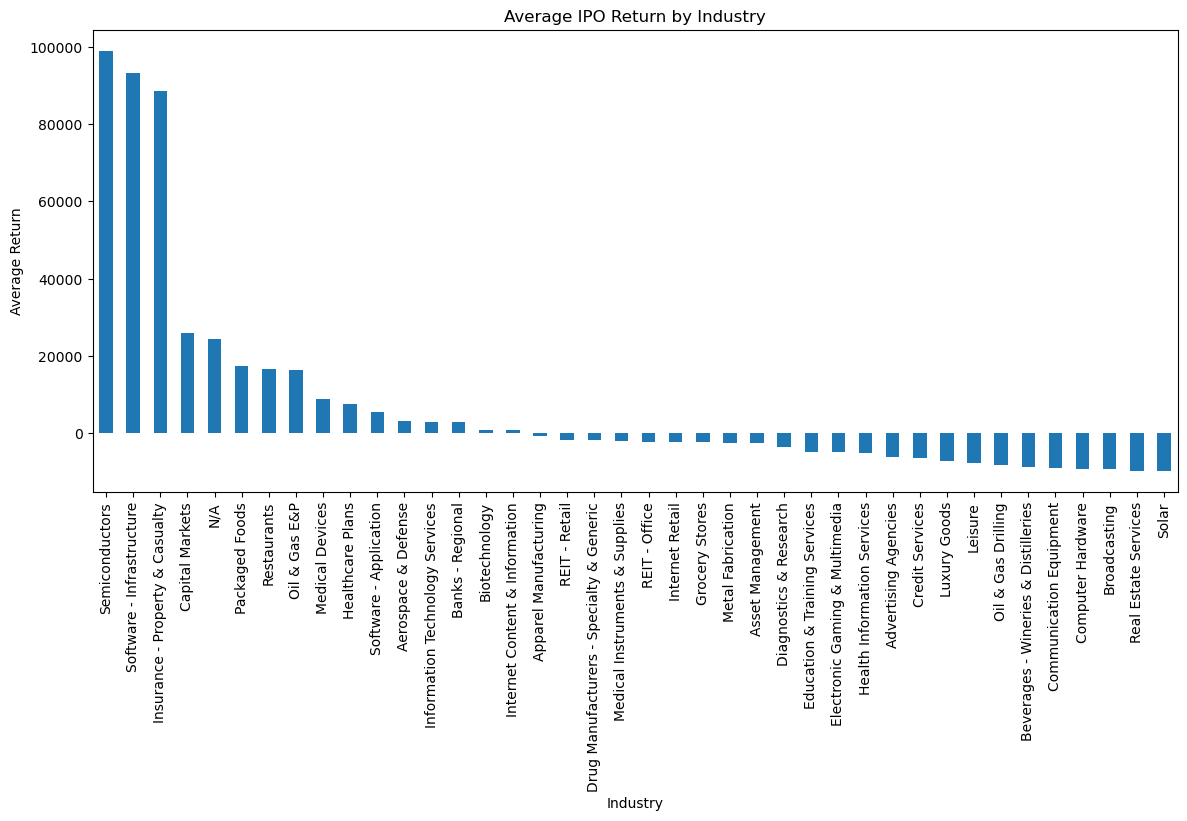

In [40]:
industry_returns.plot(kind='bar', figsize=(14,6))
plt.title('Average IPO Return by Industry')
plt.xlabel('Industry')
plt.ylabel('Average Return')
plt.xticks(rotation=90)
plt.show()

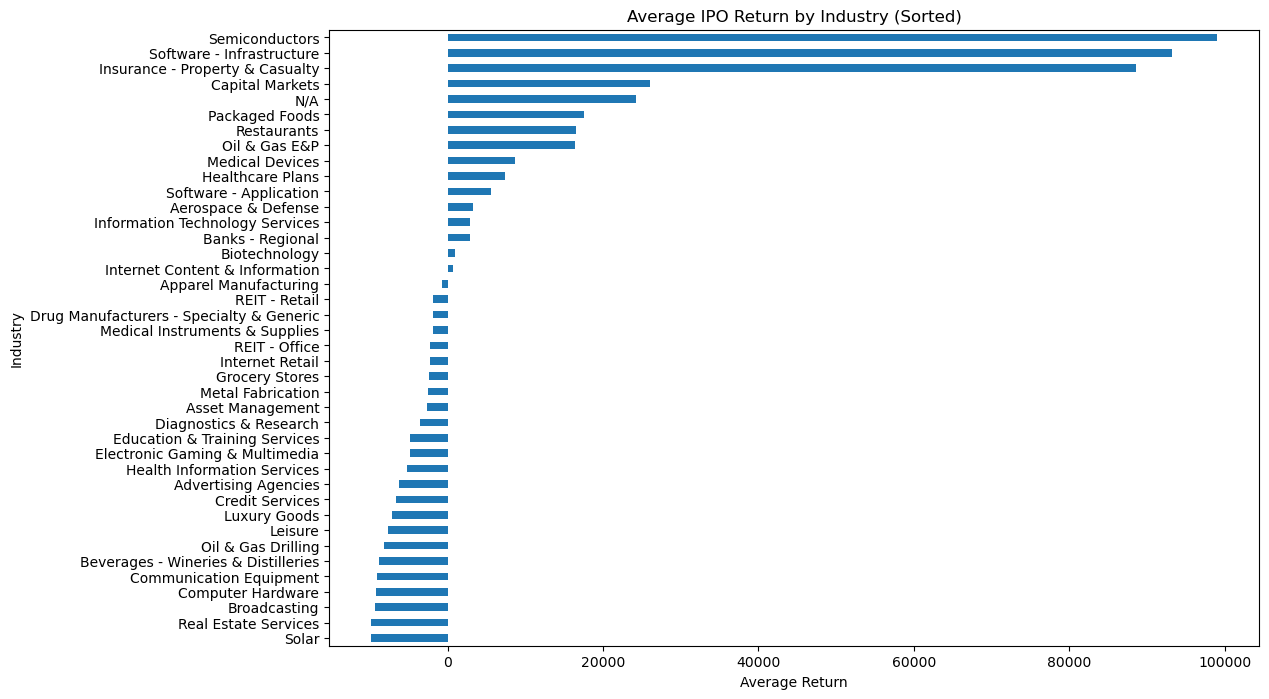

In [41]:
# Testing as a horizontal bar chart instead
industry_returns.plot(kind='barh', figsize=(12,8))
plt.title('Average IPO Return by Industry (Sorted)')
plt.xlabel('Average Return')
plt.ylabel('Industry')
plt.gca().invert_yaxis()  #making it so the largest return is at the top, instead of the bottom
plt.show()

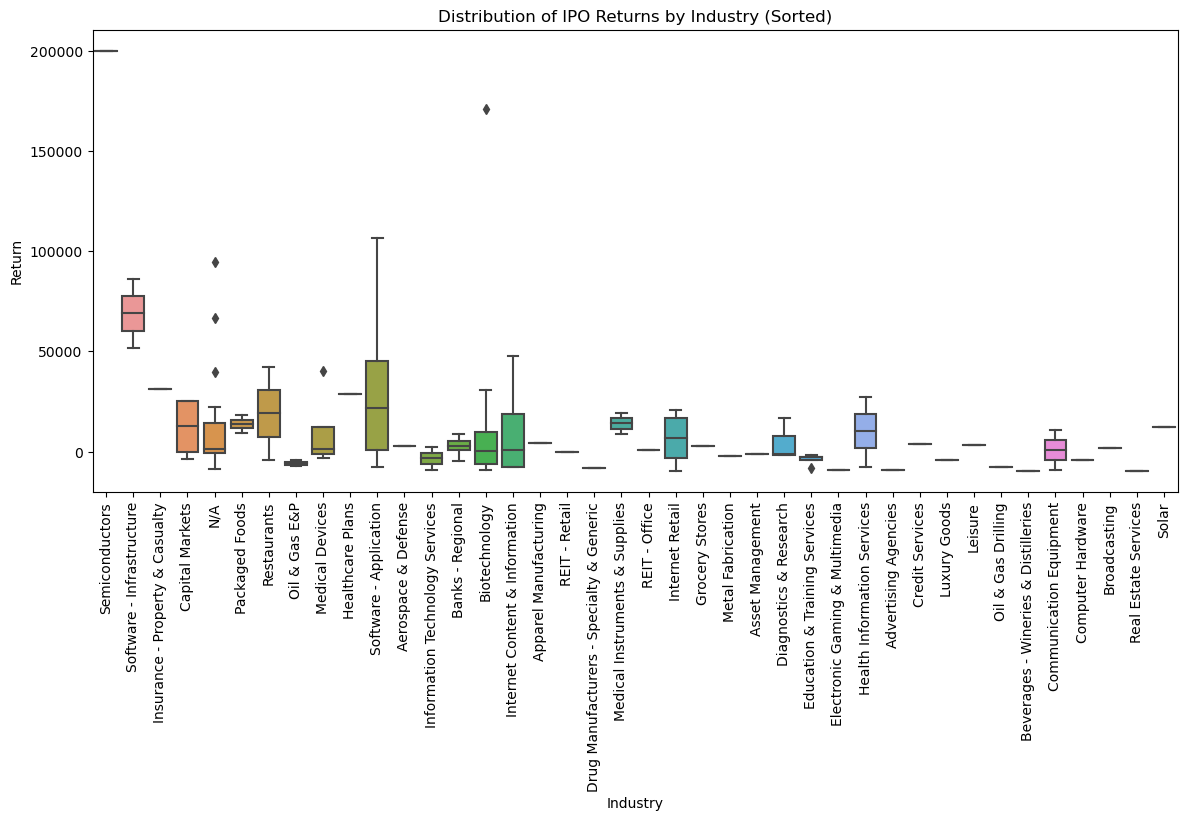

In [42]:
sorted_industries = industry_returns.index.tolist()

plt.figure(figsize=(14,6))
sns.boxplot(x='Industry', y='Return', data=merged_with_financials_clean, order=sorted_industries)
plt.xticks(rotation=90)
plt.title('Distribution of IPO Returns by Industry (Sorted)')
plt.show()

In [43]:
# Prepare list of returns by industry (matching 11-3 style)
industries = merged_with_financials_clean['Industry'].unique()
returns_list = []
for ind in industries:
    subset = merged_with_financials_clean[merged_with_financials_clean['Industry'] == ind]
    returns_list.append(subset['Return'])

# Perform tests to find F-stat and P-value
F_statistic, p_value = stats.f_oneway(*returns_list)
print('F-statistic:', F_statistic)
print('p-value:', p_value)

F-statistic: 1.997421851316214
p-value: 0.0036152359694815893


In [44]:
#Set alpha level
alpha = 0.05

#set industries to compare
industry_a = 'Restaurants'
industry_b = 'Software - Infrastructure'

#Create sample
sample_a = merged_with_financials_clean[merged_with_financials_clean['Industry'] == industry_a]['Return']
sample_b = merged_with_financials_clean[merged_with_financials_clean['Industry'] == industry_b]['Return']

#Perform two-sample t-test
t_statistic, p_value = stats.ttest_ind(sample_a, sample_b, equal_var=False)

#Print results
print("T-Statistic:", t_statistic)
print("P-Value:", p_value)

# interpretation
if p_value < alpha:
    print("Reject the null hypothesis. The mean IPO returns are significantly different between", industry_a, "and", industry_b, ".")
else:
    print("Fail to reject the null hypothesis. No significant difference between", industry_a, "and", industry_b, ".")


T-Statistic: -1.7294641133040216
P-Value: 0.23630134964958238
Fail to reject the null hypothesis. No significant difference between Restaurants and Software - Infrastructure .


# Answering question 2:	What is the optimal time to divest from an IPO? 

# Answering question 3: How does the size of a company at IPO (measured by market cap) impact its post-IPO performance? 


In [47]:
# Sort the DataFrame by Market Cap in descending order and select the top 5 companies
top_5_companies = merged_with_financials_clean.sort_values(by='Market Cap in Millions', ascending=False).head(5)

# Display the result
print(top_5_companies[['Company Name', 'Symbol', 'Market Cap in Millions', 'Return']])


          Company Name Symbol  Market Cap in Millions   Return
72     Morphic Holding   MORF                807440.0  22427.0
71   Change Healthcare   CHNG                374330.0   6192.0
78  Slack Technologies   WORK                255430.0   7385.0
96   Uber Technologies   UBER                167800.0   -673.0
31           Viela Bio    VIE                155390.0  17900.0


In [48]:
# Correct market cap for improporly imported stocks
merged_with_financials_clean.loc[merged_with_financials_clean['Symbol'] == 'WORK', 'Market Cap in Millions'] = 26520
merged_with_financials_clean.loc[merged_with_financials_clean['Symbol'] == 'MORF', 'Market Cap in Millions'] = 2862
merged_with_financials_clean.loc[merged_with_financials_clean['Symbol'] == 'CHNG', 'Market Cap in Millions'] = 9030
merged_with_financials_clean.loc[merged_with_financials_clean['Symbol'] == 'VIE', 'Market Cap in Millions'] = 2910
merged_with_financials_clean.loc[merged_with_financials_clean['Symbol'] == 'KRTX', 'Market Cap in Millions'] = 12580
merged_with_financials_clean.loc[merged_with_financials_clean['Symbol'] == 'RTLR', 'Market Cap in Millions'] = 2226 
merged_with_financials_clean.loc[merged_with_financials_clean['Symbol'] == 'TPTX', 'Market Cap in Millions'] = 3810

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [50]:
# Features and Target
X = merged_with_financials_clean[['Market Cap in Millions']]
y = merged_with_financials_clean['Return']

In [51]:
# Split into Train and Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [52]:
# Build Model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [53]:
# Predict
y_pred = model.predict(X_test)

In [54]:
# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 1179049420.1620088
R-squared: -1.0652067037302388


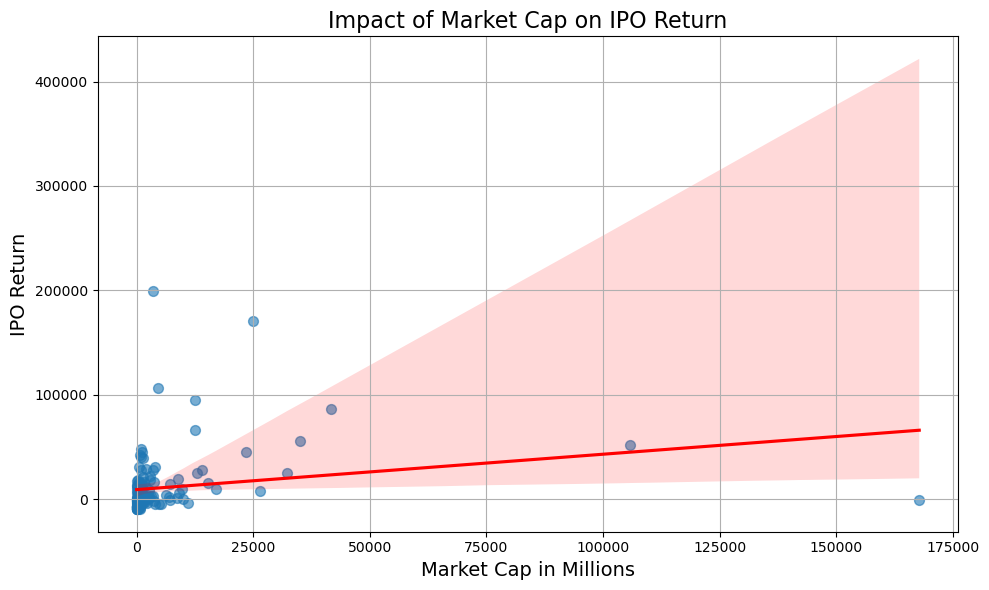

In [55]:
# Scatterplot with Regression Line
plt.figure(figsize=(10,6))
sns.regplot(
    x='Market Cap in Millions', 
    y='Return', 
    data=merged_with_financials_clean, 
    scatter_kws={'s':50, 'alpha':0.6}, 
    line_kws={'color':'red'}
)

plt.title('Impact of Market Cap on IPO Return', fontsize=16)
plt.xlabel('Market Cap in Millions', fontsize=14)
plt.ylabel('IPO Return', fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

In [56]:
# Find the IPO company in the 'Semiconductors' industry
semiconductor_company = merged_with_financials_clean[merged_with_financials_clean['Industry'] == 'Semiconductors']

# Display it
print(semiconductor_company)

       IPO Date Symbol Company Name  Current    Return  IPO Price (Float)  \
9  Nov 21, 2019   SITM       SiTime   272.84  199877.0               13.0   

   Todays Price  Current Return (%)        Industry  Market Cap in Millions  \
9        145.88             98977.0  Semiconductors                  3460.0   

   Net Income (ttm) in Millions  Revenue (ttm) in Millions  
9                         -93.6                      202.7  


In [57]:
# Save to CSV if needed
merged_with_financials_clean.to_csv("Project_Part_2_Data.csv", index=False)